In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

### parse html table

In [2]:
def parse_race_results(html_file_path):
    print(f"Reading tables from {html_file_path}...")

    # 1. Read the HTML file
    # Pandas automatically finds all <table> tags and returns a list of DataFrames
    tables = pd.read_html(html_file_path, encoding="utf-8")

    # 2. Select your table
    # Assuming the main results table is the first one in the document
    df = tables[0]

    print(f"Found table with {len(df)} rows and {len(df.columns)} columns.")

    # 3. Clean the data
    # Your HTML snippet shows the first and last columns are empty (comments/favorites).
    # Pandas usually names these empty headers "Unnamed: 0", "Unnamed: 9", etc.
    cols_to_drop = [col for col in df.columns if "Unnamed" in str(col)]
    df_cleaned = df.drop(columns=cols_to_drop)

    # Clean up string columns to remove extra whitespace or newline characters
    # (Sometimes HTML formatting leaves hidden spacing)
    for col in df_cleaned.select_dtypes(include=["object"]).columns:
        df_cleaned[col] = df_cleaned[col].str.strip()

    # 4. Export to CSV (Most universal)
    csv_filename = "race_results.csv"
    df_cleaned.to_csv(csv_filename, index=False, encoding="utf-8")
    print(f"Successfully saved to {csv_filename}")

    # 5. Export to Parquet (Most efficient for storage/speed)
    # Note: Requires the 'pyarrow' or 'fastparquet' library installed
    parquet_filename = "race_results.parquet"
    try:
        df_cleaned.to_parquet(parquet_filename, index=False)
        print(f"Successfully saved to {parquet_filename}")
    except ImportError:
        print("Tip: Install 'pyarrow' (pip install pyarrow) to enable Parquet exports.")

    return df_cleaned

In [3]:
df = parse_race_results("website.html")
df.head()

Reading tables from website.html...
Found table with 5734 rows and 10 columns.
Successfully saved to race_results.csv
Tip: Install 'pyarrow' (pip install pyarrow) to enable Parquet exports.


,Platz,Stn,Name,Verein,Jg,AK-Pl.,MW-Pl.,Zeit
0,1.0,6459,STÜTZEL Simon,LG Region Karlsruhe,1986.0,1. M,1. M,27:35
1,2.0,2,STÖCKL Christian,Feuerwehr Liedolsheim,1988.0,2. M,2. M,28:56
2,3.0,119,MÖHLER Samuel,Regierungspräsidium Karlsruhe,1996.0,3. M,3. M,29:00
3,4.0,13,WILKENS Hannes,LG Region Karlsruhe,2002.0,4. M,4. M,29:22
4,5.0,12,WEBER Yannik,LG Region Karlsruhe,1992.0,5. M,5. M,29:27


### clean and pre-process

In [4]:
df.info()
# convert all colnames to lowercase
# change platz to int
# clean strings in Name & Verein, eg we have -> FIX is to explicitly select encoding = UTF-8
# - "MÃHLER Samuel" instead of "MÖHLER Samuel"
# - "RegierungsprÃ¤sidium Karlsruhe" instead of "Regierungspräsidium Karlsruhe"
# zeit is in mm:ss -> convert to minutes as float
# also add pace ie min/km as float
# rename jg to birthyear and convert to int

# note that :
# AK-Pl. = altersklasse platz
# MW-Pl. = m/w platz

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5734 entries, 0 to 5733
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Platz   5734 non-null   float64
 1   Stn     5734 non-null   int64  
 2   Name    5734 non-null   object 
 3   Verein  4788 non-null   object 
 4   Jg      5731 non-null   float64
 5   AK-Pl.  5734 non-null   object 
 6   MW-Pl.  5734 non-null   object 
 7   Zeit    5734 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 358.5+ KB


In [5]:
def clean_df(df_raw):

    df = df_raw.copy()

    # 1. Convert all column names to lowercase
    df.columns = df.columns.str.lower()

    # 2. split names into first and last name
    # format is "LASTNAME Firstname" so we can split on the first space
    # but then there are ppl with composite last names like "VON DER HEYDEN" or "DE LA CRUZ" so we need to be careful
    # we split on last space instead of first space to handle composite last names
    # BUT what about composite first names like "ANNA MARIA" ...
    def extract_names(full_name):
        if pd.isna(full_name):
            return pd.Series([None, None])

        words = str(full_name).split()
        last_name_parts = []
        first_name_parts = []

        for word in words:
            # The Fix: Replace 'ß' with 'SS' just to trick Python's isupper()
            # "GROß" temporarily becomes "GROSS" -> isupper() is True
            # "Groß" temporarily becomes "GroSS" -> isupper() is False
            if word.replace("ß", "SS").isupper():
                last_name_parts.append(word)
            else:
                first_name_parts.append(word)

        # Rejoin the separated parts into two distinct strings
        return pd.Series([" ".join(last_name_parts), " ".join(first_name_parts)])

    # Apply the function to your dataframe to create two new columns
    df[["last_name", "first_name"]] = df["name"].apply(extract_names)
    df["gender"] = df["mw-pl."].apply(lambda x: "M" if "M" in x else "W")
    # make it binary 1 for M and 0 for W
    df["is_male"] = df["gender"].map({"M": 1, "W": 0})

    # 3. Change 'platz' to int
    df["platz"] = df["platz"].astype(int)

    # 4. Rename 'jg' and convert to int
    # CRITICAL: You have 3 missing values in the 'jg' column (5731 vs 5734).
    # Standard integer types in Python will crash if they encounter a NaN.
    # We must use Pandas' nullable integer type 'Int64' (with a capital I).
    df.rename(columns={"jg": "birthyear"}, inplace=True)
    df["birthyear"] = df["birthyear"].astype("Int64")

    # calc age at time of race ie 2026
    df["age"] = 2026 - df["birthyear"]
    bins = [0, 17, 24, 29, 39, 49, 59, 69, 99]
    labels = ["<18", "19-24", "25-29", "30-39", "40-49", "50-59", "60-69", "70+"]
    df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

    # 5. Convert 'zeit' (MM:SS or H:MM:SS) to minutes as a float
    def parse_time_to_minutes(time_str):
        if pd.isna(time_str):
            return None

        parts = str(time_str).strip().split(":")
        if len(parts) == 2:  # Format: MM:SS
            return int(parts[0]) + int(parts[1]) / 60.0
        elif len(parts) == 3:  # Format: H:MM:SS
            return (int(parts[0]) * 60) + int(parts[1]) + (int(parts[2]) / 60.0)
        return None

    df["zeit_min"] = df["zeit"].apply(parse_time_to_minutes).round(2)

    # 6. Add pace (min/km)
    # The Badische Meile is exactly 8.88889 kilometers.
    RACE_DISTANCE_KM = 8.88889

    df["pace"] = (df["zeit_min"] / RACE_DISTANCE_KM).round(2)
    # km/h speed = distance / time in hours = distance / (time in minutes / 60)
    df["speed"] = RACE_DISTANCE_KM / (df["zeit_min"] / 60)

    # 7. Add Percentile (Top X%)
    # rank(pct=True) gives 0.01 for the fastest runner and 1.0 for the slowest
    df["percentile"] = (df["platz"].rank(pct=True) * 100).round(4)

    return df


df_cleaned = clean_df(df)
df_cleaned.head()

,platz,stn,name,verein,birthyear,ak-pl.,mw-pl.,zeit,last_name,first_name,gender,is_male,age,age_group,zeit_min,pace,speed,percentile
0,1,6459,STÜTZEL Simon,LG Region Karlsruhe,1986,1. M,1. M,27:35,STÜTZEL,Simon,M,1,40,40-49,27.58,3.10,19.337687,0.0174
1,2,2,STÖCKL Christian,Feuerwehr Liedolsheim,1988,2. M,2. M,28:56,STÖCKL,Christian,M,1,38,30-39,28.93,3.25,18.435306,0.0349
2,3,119,MÖHLER Samuel,Regierungspräsidium Karlsruhe,1996,3. M,3. M,29:00,MÖHLER,Samuel,M,1,30,30-39,29.00,3.26,18.390807,0.0523
3,4,13,WILKENS Hannes,LG Region Karlsruhe,2002,4. M,4. M,29:22,WILKENS,Hannes,M,1,24,19-24,29.37,3.30,18.159122,0.0698
4,5,12,WEBER Yannik,LG Region Karlsruhe,1992,5. M,5. M,29:27,WEBER,Yannik,M,1,34,30-39,29.45,3.31,18.109793,0.0872


### simple stats

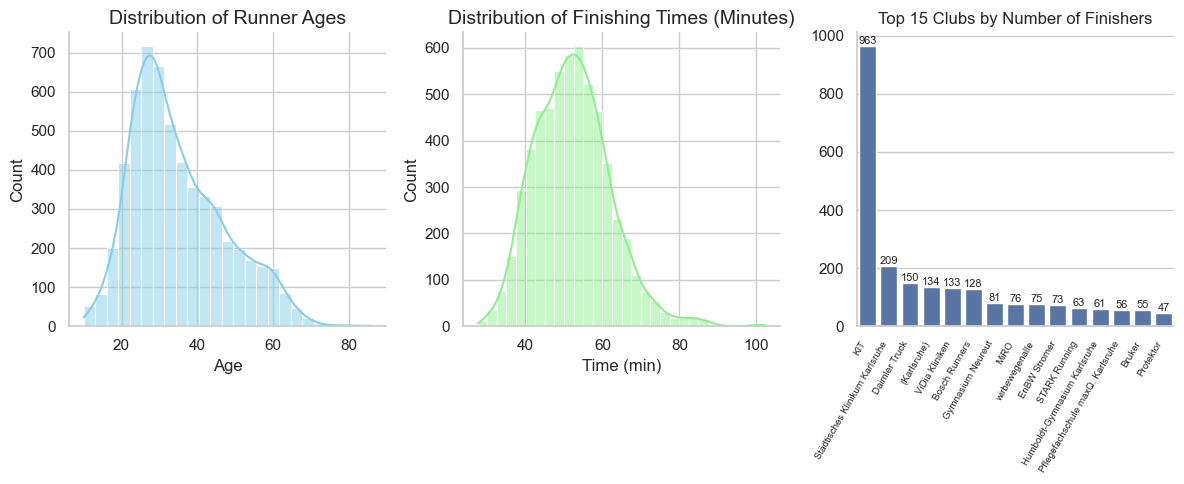

In [6]:
# do some statistics plots
# distribution of ages in 'age' column
# distribution of finishing times in minutes in 'zeit_min' column
# distribution of pace in 'pace_min_per_km' column
# top vereine by number of finishers


def get_plots(df):

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    ax1, ax2, ax3 = axes

    # --- Distribution of Ages ---
    sns.histplot(data=df, x="age", bins=25, kde=True, color="skyblue", ax=ax1)
    ax1.set_title("Distribution of Runner Ages", fontsize=14)
    ax1.set_xlabel("Age")
    ax1.set_ylabel("Count")

    # --- Distribution of Finishing Times ---
    sns.histplot(data=df, x="zeit_min", bins=30, kde=True, color="lightgreen", ax=ax2)
    ax2.set_title("Distribution of Finishing Times (Minutes)", fontsize=14)
    ax2.set_xlabel("Time (min)")
    ax2.set_ylabel("Count")

    # --- Top Vereine by Finishers ---
    # Using your 'verein' column, dropping NaNs automatically
    top_vereine = df["verein"].value_counts().nlargest(15)
    sns.barplot(
        x=top_vereine.index,
        y=top_vereine.values,
        # hue=top_vereine.index,
        # legend=True,
        # palette="viridis",
        ax=ax3,
    )
    ax3.bar_label(ax3.containers[0], fontsize=8)
    ax3.set_title("Top 15 Clubs by Number of Finishers")
    # rotate x labels for better readability
    ax3.set_xticks(range(len(top_vereine)))
    ax3.set_xticklabels(top_vereine.index, rotation=60, ha="right", fontsize=7)
    ax3.set_ylabel("")
    ax3.set_xlabel("")

    # despine all axes for cleaner look
    sns.despine(ax=ax1)
    sns.despine(ax=ax2)
    sns.despine(ax=ax3)

    # Adjust layout so titles and labels don't overlap
    plt.tight_layout()
    plt.show()

    return fig


fig = get_plots(df_cleaned)

### more stats

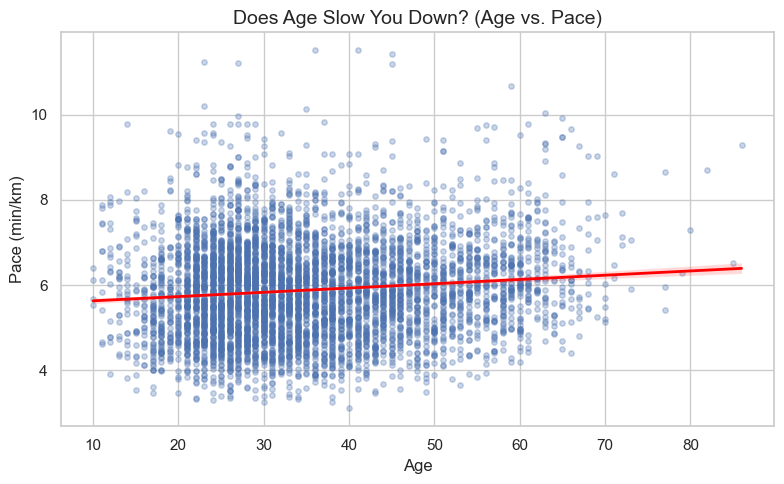

In [7]:
df_plot = df_cleaned.copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=df_plot,
    x="age",
    y="pace",
    scatter_kws={"alpha": 0.3, "s": 15},
    line_kws={"color": "red", "linewidth": 2},
    ax=ax,
)
ax.set_title("Does Age Slow You Down? (Age vs. Pace)", fontsize=14)
ax.set_xlabel("Age")
ax.set_ylabel("Pace (min/km)")

plt.tight_layout()
plt.show()

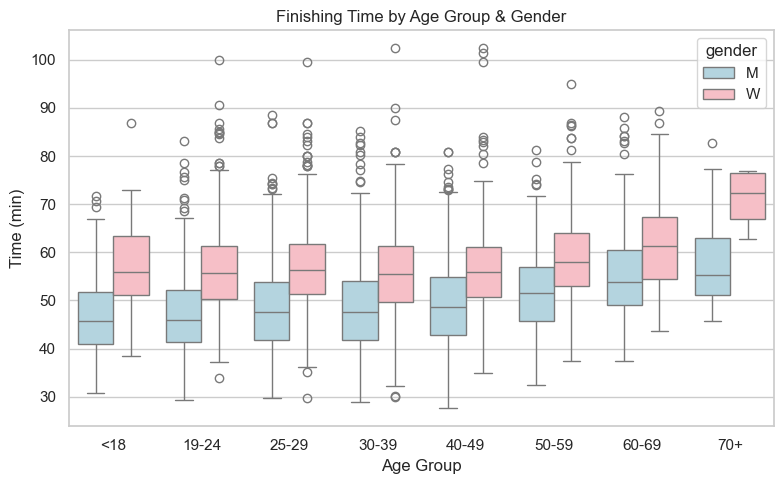

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_plot,
    x="age_group",
    y="zeit_min",
    hue="gender",
    palette={"M": "#add8e6", "W": "#ffb6c1"},
    ax=ax,
)
ax.set_title("Finishing Time by Age Group & Gender")
ax.set_xlabel("Age Group")
ax.set_ylabel("Time (min)")

plt.tight_layout()
plt.show()

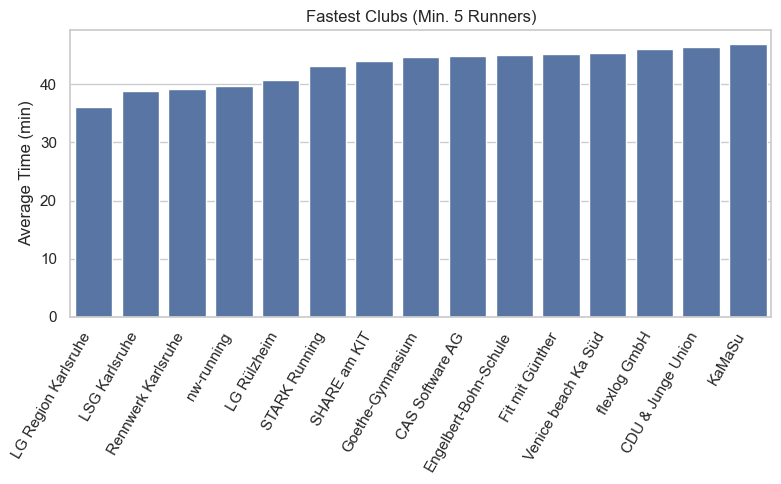

In [9]:
# --- Plot 3: The Fastest Clubs (Min 5 runners) ---
# Group by club, count runners, and find the average time
fig, ax = plt.subplots(figsize=(8, 5))
club_stats = (
    df_plot.groupby("verein")
    .agg(runner_count=("stn", "count"), avg_time=("zeit_min", "mean"))
    .reset_index()
)

# Filter for clubs with at least 5 runners to remove fast solo outliers
valid_clubs = club_stats[club_stats["runner_count"] >= 5]
fastest_clubs = valid_clubs.nsmallest(15, "avg_time")

sns.barplot(
    data=fastest_clubs,
    y="avg_time",
    x="verein",
    # palette="magma",
    # hue="verein",
    # legend=False,
    ax=ax,
)
ax.set_title("Fastest Clubs (Min. 5 Runners)")
ax.set_ylabel("Average Time (min)")
ax.set_xlabel("")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

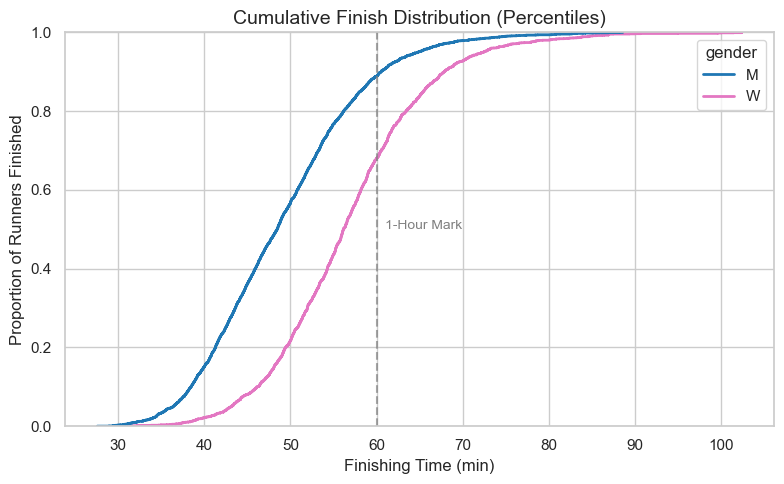

In [10]:
# --- Plot 4: Cumulative Distribution (Percentiles) ---
# Shows exactly what percentage of runners finished under X minutes
fig, ax = plt.subplots(figsize=(8, 5))
sns.ecdfplot(
    data=df_plot,
    x="zeit_min",
    hue="gender",
    palette={"M": "#1f77b4", "W": "#e377c2"},
    linewidth=2,
    ax=ax,
)
ax.set_title("Cumulative Finish Distribution (Percentiles)", fontsize=14)
ax.set_xlabel("Finishing Time (min)")
ax.set_ylabel("Proportion of Runners Finished")

# Add a helpful reference line at the 60-minute mark
ax.axvline(60, color="gray", linestyle="--", alpha=0.7)
ax.text(61, 0.5, "1-Hour Mark", color="gray", fontsize=10)

plt.tight_layout()
plt.show()

### just for fun

In [11]:
def get_name_rankings(df, gender):
    """Generates a clean Top 10 table for first and last names by gender."""
    # Get top 10 first names
    firsts = (
        df[df["gender"] == gender]["first_name"].value_counts().head(10).reset_index()
    )
    firsts.columns = ["first_name", "first_count"]

    # Get top 10 last names
    lasts = (
        df[df["gender"] == gender]["last_name"].value_counts().head(10).reset_index()
    )
    lasts.columns = ["last_name", "last_count"]

    # Concatenate side-by-side
    top_10_table = pd.concat([firsts, lasts], axis=1)

    # Shift index to start at 1 for a true "Rank" column
    top_10_table.index += 1
    top_10_table.index.name = "rank"

    return top_10_table


# Generate and print the tables
print("--- Top 10 Male Names ---")
print(get_name_rankings(df_plot, "M").to_markdown())

print("\n--- Top 10 Female Names ---")
print(get_name_rankings(df_plot, "W").to_markdown())

--- Top 10 Male Names ---
|   rank | first_name   |   first_count | last_name   |   last_count |
|-------:|:-------------|--------------:|:------------|-------------:|
|      1 | Christian    |            67 | MÜLLER      |           31 |
|      2 | Michael      |            66 | WEBER       |           13 |
|      3 | Andreas      |            60 | MAIER       |           12 |
|      4 | Tobias       |            53 | SCHÄFER     |           11 |
|      5 | Philipp      |            53 | WOLF        |           10 |
|      6 | Matthias     |            49 | SCHNEIDER   |           10 |
|      7 | Alexander    |            49 | HARTMANN    |           10 |
|      8 | Simon        |            49 | SCHMIDT     |           10 |
|      9 | Thomas       |            48 | KRAUS       |            9 |
|     10 | Lukas        |            46 | BECKER      |            9 |

--- Top 10 Female Names ---
|   rank | first_name   |   first_count | last_name   |   last_count |
|-------:|:-----------

In [12]:
# Grab the 5 most common male names
top_5_m_names = df_plot[df_plot["gender"] == "M"]["first_name"].value_counts().head(10).index

# Calculate their average finishing times
name_speed_showdown = (
    df_plot[df_plot['first_name'].isin(top_5_m_names)]
    .groupby('first_name')['zeit_min']
    .mean()
    .sort_values()
)

print("Average Finishing Time by Common Name:")
print(name_speed_showdown)

# TODO :
# doesnt this skew in favour of more frequent names ? 
# or rather, how to paint the fuller picture ? add counts ?
# or not only sample from top names ?

Average Finishing Time by Common Name:
first_name
Lukas        46.137174
Philipp      47.234151
Tobias       47.809057
Simon        48.044490
Alexander    48.055918
Michael      49.320303
Matthias     49.406122
Christian    49.635821
Andreas      51.852333
Thomas       51.927083
Name: zeit_min, dtype: float64


In [13]:
# Group by club and last name, filtering out independent runners without a club
dynasties = df_plot.dropna(subset=['verein']).groupby(['verein', 'last_name']).size().reset_index(name='family_members')

# Show the top 5 biggest families in a single club
biggest_dynasties = dynasties.sort_values(by='family_members', ascending=False).head(10)

print("Biggest Family Dynasties:")
print(biggest_dynasties)

Biggest Family Dynasties:
                        verein  last_name  family_members
2304                       KIT     WAGNER               6
1263            Grund-Ausdauer      GRUND               5
779                 DAR Maliha     MALIHA               5
1312         Gymnasium Neureut      KRÄTZ               5
2318                       KIT       WEIß               5
2312                       KIT      WEBER               5
1707                       KIT      FRANK               5
3286             Running Deers        REH               5
938     Der Weg ist das Ziel !    GANTNER               5
3468  Schmerler Elektrotechnik  SCHMERLER               4


In [14]:
# People who finished between 1:00:01 and 1:00:15
heartbreakers = df_plot[(df_plot['zeit_min'] > 60.0) & (df_plot['zeit_min'] <= 60.25)]

print(f"Number of runners who missed the 1-hour mark by seconds: {len(heartbreakers)}")
heartbreakers[['name', 'zeit', 'verein', 'age', 'gender']]

Number of runners who missed the 1-hour mark by seconds: 38


,name,zeit,verein,age,gender
4607,MÜLLER Kevin,1:00:01,Team Haifischbar,31,M
4608,KNÖFEL Dorothee,1:00:02,TUS Rüppurr,39,W
4609,REIMANN Katahrina,1:00:03,Humboldt-Gymnasium Karlsruhe,18,W
4610,FREIBERGER Csaba,1:00:04,Krokodile Karlsruhe,30,M
4611,STEINHAGEN Kevin,1:00:04,NaN,33,M
4612,SENNE Volker,1:00:04,Das S-Team,64,M
4613,SENNE Jakob,1:00:04,Das S-Team,38,M
4614,SCHÄFER Davina,1:00:06,wirbewegenalle,28,W
4615,SCHÄFER Thomas,1:00:06,Gesamtsieger,62,M
4616,BAUDY Sven,1:00:06,MiRO,42,M


In [15]:
# Count runners per club
club_counts = df_plot['verein'].value_counts()

# Filter for clubs that only have exactly 1 finisher
lone_wolves = club_counts[club_counts == 1]

print(f"Total clubs with only one finisher: {len(lone_wolves)}")
print("Sample of Lone Wolf Clubs:")
print(lone_wolves.sample(20)) # Prints 5 random single-person clubs

Total clubs with only one finisher: 263
Sample of Lone Wolf Clubs:
verein
Merquez & Jetski           1
SSC                        1
NETSYNO                    1
SV Nassig                  1
Lauffreunde Schuju         1
VeniceBeach                1
JVA Bruchsal               1
Stermel                    1
Die Brüderschaft           1
(Steinheim an der Murr)    1
Ingenieurbüro Kluge        1
KIT-IAM WK                 1
(Jockgrim)                 1
SanusEnergy.ch             1
Team Schneider             1
Les Tortues Agiles         1
Bubu&Dudu                  1
(Kieselbronn)              1
TSG Wiesloch               1
LASJogger                  1
Name: count, dtype: int64


In [22]:
def get_ego_check_stats(df, first_name, last_name):
    # 1. Locate the runner in the dataset
    runner = df[(df['first_name'] == first_name) & (df['last_name'] == last_name)]
    
    if runner.empty:
        return f"Runner '{first_name} {last_name}' not found! Check your spelling."
        
    # Extract their specific stats
    target_time = runner['zeit_min'].values[0]
    target_time_str = runner['zeit'].values[0]
    runner_age = runner['age'].values[0]
    runner_gender = runner['gender'].values[0]
    runner_rank = runner['platz'].values[0]
    runner_percentile = runner['percentile'].values[0]
    
    # 2. Isolate everyone who crossed the finish line BEFORE them
    faster_runners = df[df['zeit_min'] < target_time].copy()
    
    if faster_runners.empty:
        return f"Congratulations {first_name}, you literally won the race. No one was faster."

    # 3. Calculate the fun stats
    oldest_faster = faster_runners.loc[faster_runners['age'].idxmax()]
    youngest_faster = faster_runners.loc[faster_runners['age'].idxmin()]
    seniors_faster = len(faster_runners[faster_runners['age'] >= 70])
    
    years_older = int(oldest_faster['age'] - runner_age) if pd.notna(runner_age) and pd.notna(oldest_faster['age']) else "?"
    years_younger = int(runner_age - youngest_faster['age']) if pd.notna(runner_age) and pd.notna(youngest_faster['age']) else "?"

    if pd.notna(runner_age):
        same_age_runners = df[df['age'] == runner_age]
        total_same_age = len(same_age_runners)
        same_age_faster = len(same_age_runners[same_age_runners['zeit_min'] < target_time])
        
        # Calculate rank and percentile within their exact age
        age_rank = same_age_faster + 1
        age_percentile = (age_rank / total_same_age) * 100
    else:
        total_same_age = 0

    opposite_gender = 'W' if runner_gender == 'M' else 'M'
    opp_gender_faster_count = len(faster_runners[faster_runners['gender'] == opposite_gender])
    
    # --- UPDATED: The Identity Theft Filters ---
    # 1. Exact Name Clone
    exact_clones = faster_runners[(faster_runners['first_name'] == first_name) & (faster_runners['last_name'] == last_name)]
    # 2. First Name Rival
    first_name_rivals = faster_runners[(faster_runners['first_name'] == first_name) & (faster_runners['last_name'] != last_name)]
    # 3. Last Name Rival
    last_name_rivals = faster_runners[(faster_runners['last_name'] == last_name) & (faster_runners['first_name'] != first_name)]
    
    # The Sprint Regret Filters
    faster_runners['sec_diff'] = ((target_time - faster_runners['zeit_min']) * 60).round().astype(int)
    sprint_rivals = faster_runners[(faster_runners['sec_diff'] >= 1) & (faster_runners['sec_diff'] <= 10)]
    
    # 4. Print the interactive report
    print("= "*40)
    print(f"🏁 THE EGO CHECK REPORT: {first_name} {last_name}")
    print("- "*40)
    print(f"Your Time: {target_time_str} | Overall Rank: #{runner_rank} | Top {runner_percentile:.2f}%") 
    print("- "*40)

    if total_same_age > 1:
        print(f"🎂 THE CLASS REUNION (Age {runner_age}):")
        print(f"   There were {total_same_age} runners exactly your age on the course.")
        print(f"   Among them, you placed #{age_rank} (Top {age_percentile:.1f}%).")
        if same_age_faster == 0:
            print(f"   You are the undisputed champion of your birth year. Flawless victory.")
        print("") # Blank line for spacing
    
    print(f"👴 THE VETERAN:")
    print(f"   The oldest person to beat you was {oldest_faster['first_name']} {oldest_faster['last_name']}.")
    print(f"   They are {oldest_faster['age']} years old ({years_older} years older than you!) and finished in {oldest_faster['zeit']}.")
    
    print(f"\n👶 THE ROOKIE:")
    print(f"   The youngest person to beat you was {youngest_faster['first_name']} {youngest_faster['last_name']}.")
    print(f"   They are only {youngest_faster['age']} years old ({years_younger} years younger than you!) and finished in {youngest_faster['zeit']}.")
    
    print(f"\n🦾 THE SUPER SENIORS:")
    if seniors_faster > 0:
        print(f"   Ouch. There were {seniors_faster} runners aged 70 or older who finished before you.")
    else:
        print("   Good news: You successfully outran every single 70+ year old in the race!")

    # print(f"\n🏃‍♀️ THE GENDER REALITY:")
    # if opp_gender_faster_count > 0:
    #     gender_label = "women" if opposite_gender == 'W' else "men"
    #     print(f"   A total of {opp_gender_faster_count} {gender_label} crossed the finish line before you did.")
    # else:
    #     print("   You were the fastest of your gender. Elite.")

    # --- UPDATED: The Identity Theft Output ---
    print(f"\n🪪 THE IDENTITY THEFT:")
    if not exact_clones.empty:
        clone = exact_clones.iloc[0]
        print(f"   🚨 DOPPELGÄNGER ALERT 🚨")
        print(f"   There is literally another person named '{first_name} {last_name}' who ran this race.")
        print(f"   Worse? They beat you by {round(target_time - clone['zeit_min'], 1)} minutes.")
        print(f"   They are officially the superior '{first_name} {last_name}'.")
    else:
        if not first_name_rivals.empty:
            fastest_first = first_name_rivals.iloc[0]
            print(f"   You aren't even the fastest '{first_name}'.")
            print(f"   {fastest_first['first_name']} {fastest_first['last_name']} finished {round(target_time - fastest_first['zeit_min'], 1)} minutes ahead of you.")
        elif not last_name_rivals.empty:
            fastest_last = last_name_rivals.iloc[0]
            print(f"   You aren't even the fastest '{last_name}'.")
            print(f"   {fastest_last['first_name']} {fastest_last['last_name']} finished {round(target_time - fastest_last['zeit_min'], 1)} minutes ahead of you.")

    print(f"\n⏱️ THE SPRINT REGRET:")
    if not sprint_rivals.empty:
        closest_rival = sprint_rivals.sort_values('sec_diff').iloc[0]
        seconds_diff = closest_rival['sec_diff']
        places_lost = runner_rank - closest_rival['platz']
        
        print(f"   If you had just pushed a tiny bit harder, you could have beaten {closest_rival['first_name']} {closest_rival['last_name']}.")
        print(f"   They beat you by exactly {seconds_diff} seconds.")
        
        if len(sprint_rivals) > 3:
            print(f"   In fact, a total of {len(sprint_rivals)} runners sneaked past you in those last 10 secs.")
    else:
        print("   You had plenty of breathing room. The person ahead of you was either a dead-heat tie or way out of sight.")
        
    print("= "*40)

first = 'Simon'
last = 'Schmitz'
get_ego_check_stats(df_plot, first, last.upper())

= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
🏁 THE EGO CHECK REPORT: Simon SCHMITZ
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Your Time: 44:31 | Overall Rank: #1328 | Top 23.16%
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
🎂 THE CLASS REUNION (Age 26):
   There were 238 runners exactly your age on the course.
   Among them, you placed #60 (Top 25.2%).

👴 THE VETERAN:
   The oldest person to beat you was Reinhard MUSSLER.
   They are 67 years old (41 years older than you!) and finished in 42:35.

👶 THE ROOKIE:
   The youngest person to beat you was Noah KNAM.
   They are only 11 years old (15 years younger than you!) and finished in 40:58.

🦾 THE SUPER SENIORS:
   Good news: You successfully outran every single 70+ year old in the race!

🪪 THE IDENTITY THEFT:
   You aren't even the fastest 'Simon'.
   Simon STÜTZEL finished 16.9 minutes ahead of you.

⏱️ THE SPRINT REGRET:
   If